In [69]:
import os
import pandas as pd

base_path  = "/Users/lsieben/Desktop/Benchmarking/active_learning/acquisition_fct/results_collins_and_coadd"
acq_funcs  = ["random", "greedy", "ucb", "bald"]
replicates = range(3)  # rep_0, rep_1, rep_2

results = {acq: {} for acq in acq_funcs}

for acq in acq_funcs:
    for rep in replicates:
        csv_path = os.path.join(base_path, f"results_rep_{rep}", f"al_{acq}.csv")
        try:
            results[acq][rep] = pd.read_csv(csv_path)
        except FileNotFoundError:
            print(f"⚠️  Warning: {csv_path} not found — skipping.")
            # keep the slot but mark as missing
            results[acq][rep] = None

# convenient unpacking (lists will contain None where a replicate is missing)
results_random  = [results["random"].get(r)  for r in replicates]
results_greedy  = [results["greedy"].get(r)  for r in replicates]
results_ucb     = [results["ucb"].get(r)     for r in replicates]
#results_entropy = [results["entropy"].get(r) for r in replicates]
results_bald    = [results["bald"].get(r)    for r in replicates]

results_bald[0].tail(5)

,iteration,n_labeled,n_hits,pct_molecules_acquired,pct_hits_discovered
46,46,10200,211.0,8.516536,61.516035
47,47,10400,212.0,8.683527,61.807580
48,48,10600,212.0,8.850518,61.807580
49,49,10800,214.0,9.017509,62.390671
50,50,11000,214.0,9.184500,62.390671


In [45]:
results_bald[0].tail(5)

,iteration,n_labeled,n_hits,pct_molecules_acquired,pct_hits_discovered
46,46,10200,211.0,8.516536,61.516035
47,47,10400,212.0,8.683527,61.807580
48,48,10600,212.0,8.850518,61.807580
49,49,10800,214.0,9.017509,62.390671
50,50,11000,214.0,9.184500,62.390671


In [41]:
import pandas as pd
import matplotlib.pyplot as plt

collins_ec = pd.read_csv("/Users/lsieben/Desktop/AL_for_Broadspectrum/Iteration_0/data/Collins/Collins_EC_cleaned.csv")
num_active = collins_ec["Hit"].sum()
print(f"There are {num_active} actives out of {len(collins_ec)} in the Collins EC")

def plot_active_learning_progress(loco_df, total_mols=38770, total_hits=212):

    # Plot  
    plt.plot(loco_df['pct_molecules_acquired'], loco_df['pct_hits_discovered'], marker='o', label='Active Learning')
    plt.xlabel("Cumulative % of Molecules Acquired")
    plt.ylabel("Cumulative % of Hits Discovered")
    plt.title("Hit Discovery vs. Molecules Acquired")
    plt.grid(True)
    plt.legend()
    plt.xlim(0, 100)
    plt.ylim(0, 100)
    plt.show()

def plot_multiple_active_learning_runs(dfs, labels, total_mols=38770, total_hits=212):
    """
    Plots cumulative % hits discovered vs. % molecules acquired
    for multiple active learning runs.
    
    Parameters:
        dfs (list of pd.DataFrame): each with columns ['iteration', 'molecules_acquired', 'hits_acquired']
        labels (list of str): labels for each curve
        total_mols (int): total number of molecules
        total_hits (int): total number of hits
    """
    assert len(dfs) == len(labels), "Number of dataframes and labels must match"

    for df, label in zip(dfs, labels):
        plt.plot(df['pct_molecules_acquired'], df['pct_hits_discovered'], label=label)

    plt.xlabel("Cumulative % of Molecules Acquired")
    plt.ylabel("Cumulative % of Hits Discovered")
    plt.title("Hit Discovery vs. Molecules Acquired")
    plt.grid(True)
    plt.legend()
    plt.xlim(0, 10)
    plt.ylim(0, 110)
    plt.show()

There are 212.0 actives out of 38770 in the Collins EC


In [71]:
import numpy as np
import matplotlib.pyplot as plt

def plot_al_with_replicate_range(
    results,
    acq_funcs=None,
    replicates=range(3),
    title='',
    colors=None,              # ← NEW: list of hex / matplotlib colours
    labels=None,
):
    """
    Plot mean ± range (min–max) across replicates for each acquisition function.

    Parameters
    ----------
    results     : dict  — results[acq][rep] → DataFrame with
                           ['pct_molecules_acquired', 'pct_hits_discovered']
    acq_funcs   : list  — acquisition functions to plot (defaults to all keys)
    replicates  : list/iterable of replicate indices to use
    colors      : list  — colour for each acquisition function (same order
                           as acq_funcs).  If None, use Matplotlib defaults.
    """
    if acq_funcs is None:
        acq_funcs = list(results.keys())

    if colors is None:
        # Let matplotlib choose default colour cycle
        colors = [None] * len(acq_funcs)
    else:
        assert len(colors) >= len(acq_funcs), (
            "Need at least as many colours as acquisition functions"
        )

    # Set font to Arial
    plt.rcParams['font.family'] = 'Arial'
    # You can also set other font properties if needed
    plt.rcParams['font.size'] = 12  # Base font size
    plt.figure(figsize=(14, 8))
    i = 0

    for acq, col in zip(acq_funcs, colors):
        # grab available replicates
        reps = [results[acq].get(r) for r in replicates
                if results[acq].get(r) is not None]
        if not reps:
            print(f"⚠️  No data for acquisition function '{acq}' — skipping.")
            continue

        # assumes every replicate shares the same x-grid
        x = reps[0]['pct_molecules_acquired'].values
        y_stack = np.vstack([rep['pct_hits_discovered'].values for rep in reps])

        y_mean = y_stack.mean(axis=0)
        y_min  = y_stack.min(axis=0)
        y_max  = y_stack.max(axis=0)

        if labels is None: label = acq.capitalize()
        else: label = labels[i]
        i += 1
        
        plt.plot(x, y_mean, label=label, color=col)
        plt.fill_between(x, y_min, y_max, alpha=0.25, color=col)

    plt.xlabel("Cumulative % of Molecules Acquired")
    plt.ylabel("Cumulative % of Hits Discovered")
    plt.title("Active Learning: Comparison of Acquisition Functions", fontweight='bold')
    plt.grid(True)
    plt.xlim(0, 9.5)
    plt.ylim(0, 110)
    plt.xticks(np.arange(0, 9.5, 0.5))

    # legend outside the plot
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
    plt.tight_layout()
    plt.savefig(title)

## Get the new data from supercloud

I've repeated these experimentes 3x total on supercloud, maybe in the end have a shaded area to show range

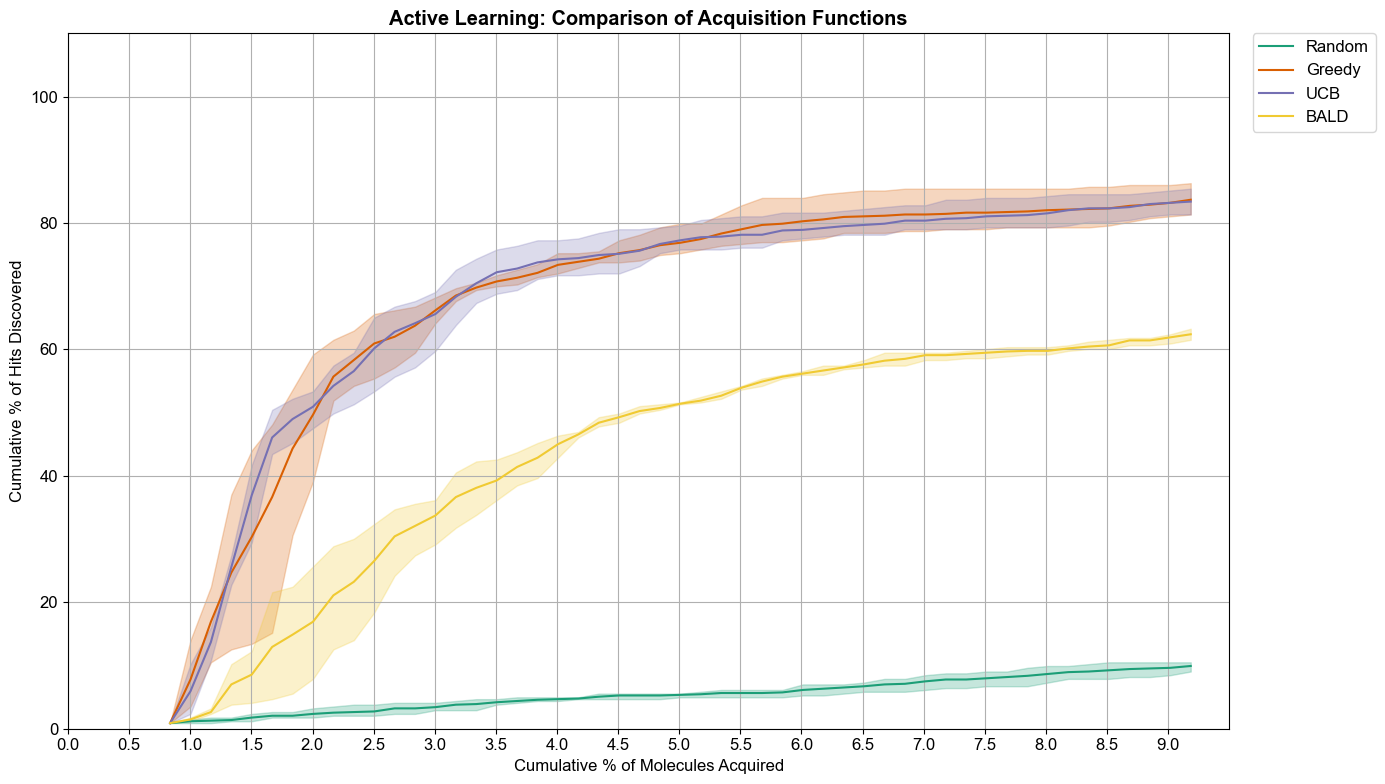

In [72]:
custom_colors = ["#1b9e77", "#d95f02", "#7570b3", "#f0ca32"]

plot_al_with_replicate_range(results, title='comparison_acquisition_functions.png', colors=custom_colors, labels=["Random", "Greedy", "UCB", "BALD"])


In [60]:
results_greedy[0]

,iteration,n_labeled,n_hits,pct_molecules_acquired,pct_hits_discovered
0,0,1000,3.0,0.834955,0.874636
1,1,1200,48.0,1.001945,13.994169
2,2,1400,77.0,1.168936,22.448980
3,3,1600,127.0,1.335927,37.026239
4,4,1800,151.0,1.502918,44.023324
5,5,2000,165.0,1.669909,48.104956
6,6,2200,184.0,1.836900,53.644315
7,7,2400,203.0,2.003891,59.183673
8,8,2600,211.0,2.170882,61.516035
9,9,2800,216.0,2.337873,62.973761


In [61]:
79.88/5

15.975999999999999

In [16]:
0.0025*120000

300.0

In [13]:
pd.read_csv("/Users/lsieben/Desktop/AL_for_Broadspectrum/MiniMol_AL_toy_examples/241231_MiniMol_projects/AL_acq_fct_results/al_results_greedy_ensemble=5.csv")

,iteration,hits_discovered,pct_molecules_acquired,pct_hits_discovered
0,0,11,0.000000,2.600473
1,1,57,0.249387,13.475177
2,2,114,0.498774,26.950355
3,3,170,0.748161,40.189125
4,4,229,0.997548,54.137116
5,5,245,1.246935,57.919622
6,6,256,1.496322,60.520095
7,7,270,1.745708,63.829787
8,8,282,1.995095,66.666667
9,9,290,2.244482,68.557920


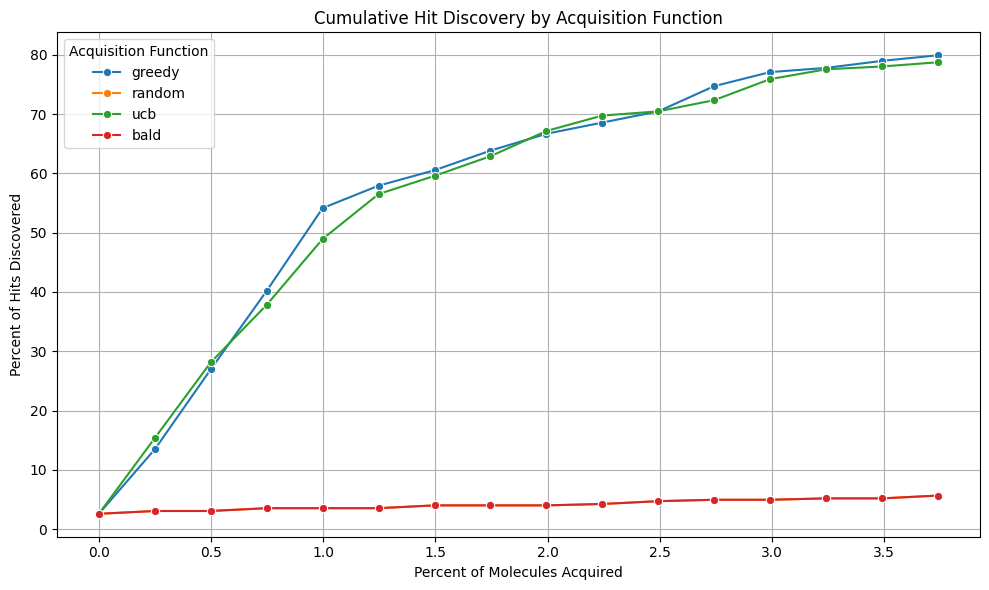

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load all your acquisition function results
file_paths = {
    "greedy": "/Users/lsieben/Desktop/AL_for_Broadspectrum/MiniMol_AL_toy_examples/241231_MiniMol_projects/AL_acq_fct_results/al_results_greedy_ensemble=5.csv",
    "random": "/Users/lsieben/Desktop/AL_for_Broadspectrum/MiniMol_AL_toy_examples/241231_MiniMol_projects/AL_acq_fct_results/al_results_random.csv",
    "ucb": "/Users/lsieben/Desktop/AL_for_Broadspectrum/MiniMol_AL_toy_examples/241231_MiniMol_projects/AL_acq_fct_results/al_results_ucb_beta=2_ensemble=5.csv",
    "bald": "/Users/lsieben/Desktop/AL_for_Broadspectrum/MiniMol_AL_toy_examples/241231_MiniMol_projects/AL_acq_fct_results/al_results_bald.csv"
}

# Load and tag data
dfs = []
for name, path in file_paths.items():
    df = pd.read_csv(path)
    df["acquisition_function"] = name
    dfs.append(df)

# Combine all results into one DataFrame
all_data = pd.concat(dfs, ignore_index=True)

# Convert fractions to percentages
all_data["% molecules acquired"] = all_data["pct_molecules_acquired"] 
all_data["% hits discovered"] = all_data["pct_hits_discovered"] 

# Plotting
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=all_data,
    x="% molecules acquired",
    y="% hits discovered",
    hue="acquisition_function",
    marker="o"
)
plt.title("Cumulative Hit Discovery by Acquisition Function")
plt.xlabel("Percent of Molecules Acquired")
plt.ylabel("Percent of Hits Discovered")
plt.grid(True)
plt.legend(title="Acquisition Function")
plt.tight_layout()
plt.show()
